<div style="text-align: center;">
    <img src="/home/yslcoat/projects/how_to_train_your_vit_pytorch/figures/hierarchical_image_resolution_vit.jpg" width="800" height="600">
</div>

### IDEA: 
- Tokenize the input image at different levels of resolution.
- Downscale the image to fit the different levels in the hierarchy
- Perform cross attention on the different levels in the hierarchy

### Questions
1. Separate tokenization technique? Output flows into standard vit architecture?
2. What do we benefit from adding the lower layers in the hierarchi?
    - The smaller image resolutions will arguably be so blurry there might not be any information there
    - How will the model benefit from these blurry cells

### Goals
1. Potentially can process images of higher resolution better,  we might not 

In [ ]:
IMAGE_PATH = r"/home/yslcoat/data/imagenet1k/ILSVRC/Data/CLS-LOC/train/n01614925/n01614925_87.JPEG"
TARGET_RESOLUTION = (224, 224)
PATCH_SIZE = (16, 16)

In [6]:
max_hierarchical_levels = (TARGET_RESOLUTION[0] // PATCH_SIZE[0], TARGET_RESOLUTION[1] // PATCH_SIZE[1])
max_hierarchical_levels

(14, 14)

In [15]:
RESOLUTION_LEVELS = list(range(PATCH_SIZE[0], TARGET_RESOLUTION[0] + 1, PATCH_SIZE[0]))
RESOLUTION_LEVELS

[16, 32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224]

In [ ]:
import PIL
import PIL.Image

In [9]:
def load_image(image_path):
    image = PIL.Image.open(image_path)
    image = image.resize(TARGET_RESOLUTION, PIL.Image.LANCZOS)
    return image

In [10]:
loaded_image = load_image(IMAGE_PATH)

In [11]:
import matplotlib.pyplot as plt

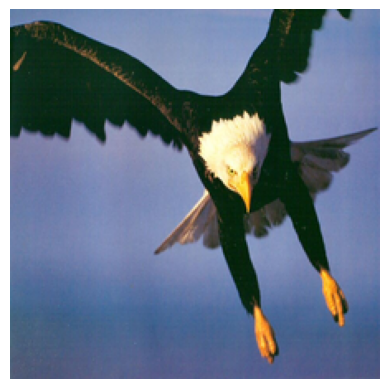

In [12]:
plt.imshow(loaded_image)
plt.axis("off")
plt.show()

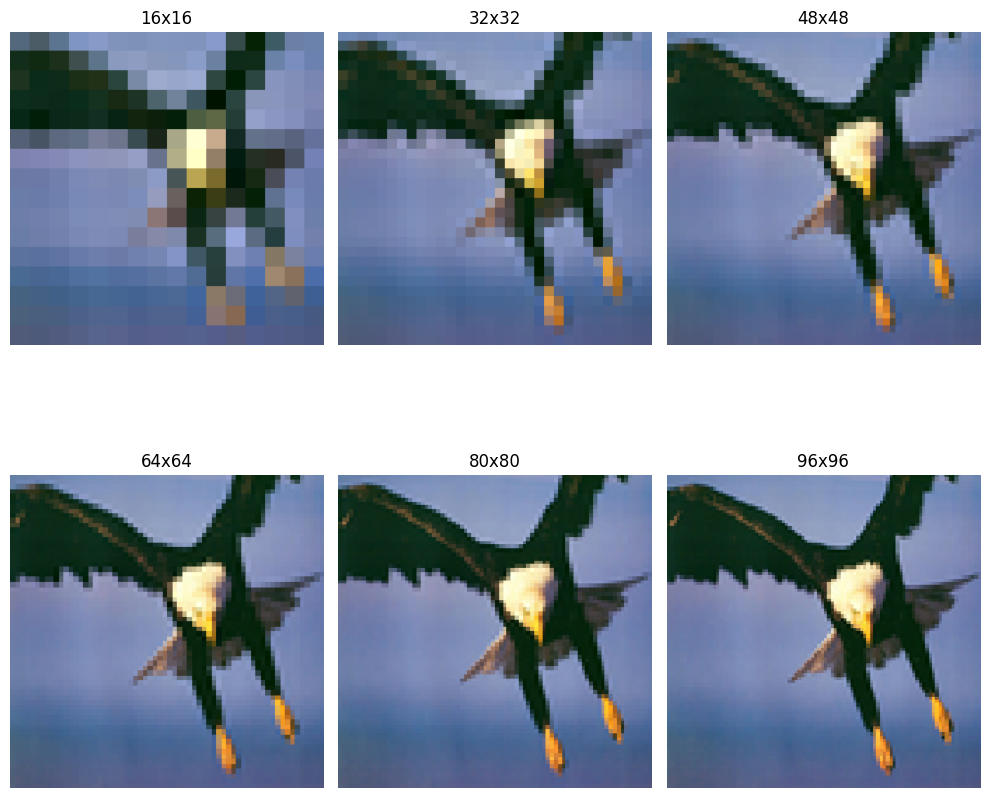

In [24]:
import math

cols = 3
rows = math.ceil(len(RESOLUTION_LEVELS[:6]) / cols)

fig, axs = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axs_flat = axs.flatten()

for ax, level in zip(axs_flat, RESOLUTION_LEVELS[:6]):
    low_res = loaded_image.resize((level, level), PIL.Image.LANCZOS)
    pixelated = low_res.resize((224, 224), PIL.Image.NEAREST)

    ax.imshow(pixelated)
    ax.set_title(f"{level}x{level}")
    ax.axis("off")

for i in range(len(RESOLUTION_LEVELS[:6]), len(axs_flat)):
    axs_flat[i].axis('off')

plt.tight_layout()
plt.show()

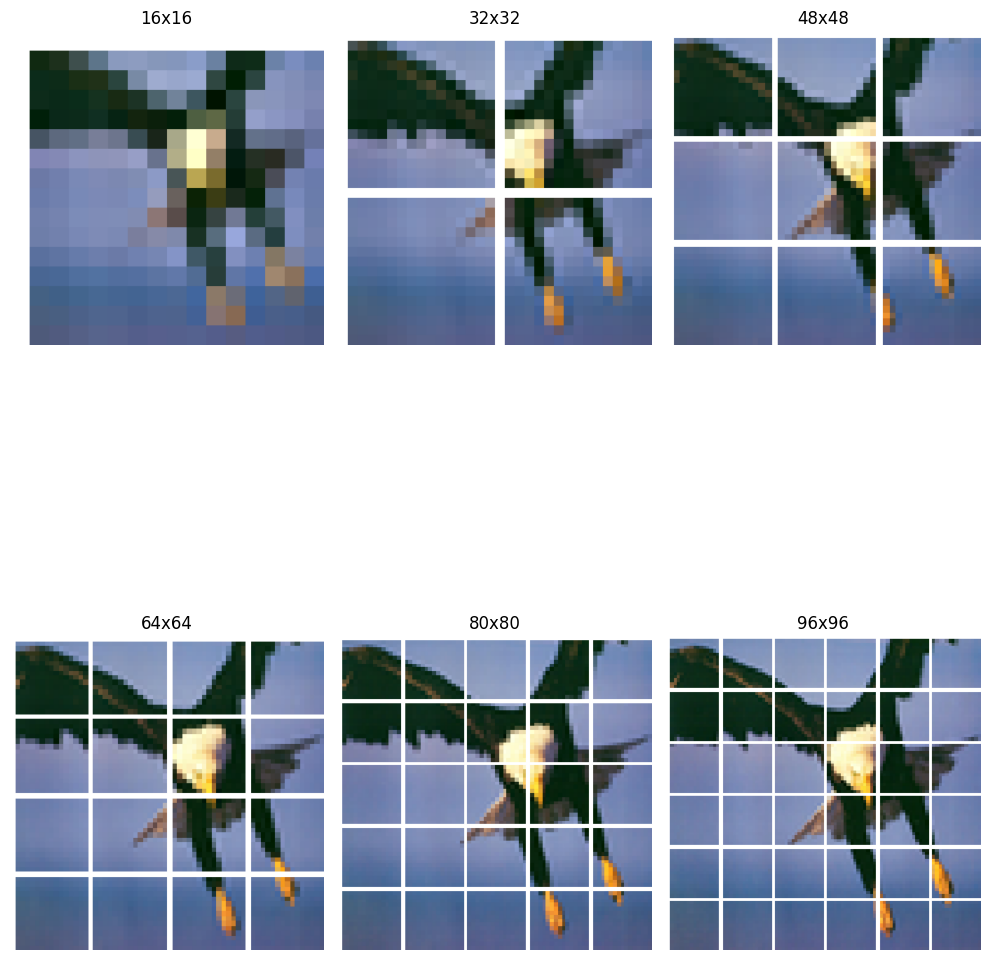

In [35]:
from PIL import ImageDraw
fig, axs = plt.subplots(2, 3, figsize=(10, 5 * rows))
axs_flat = axs.flatten()

for ax, level in zip(axs_flat, RESOLUTION_LEVELS[:6]):
    n_patches = level // PATCH_SIZE[0]
    low_res = loaded_image.resize((level, level), PIL.Image.LANCZOS)

    draw = ImageDraw.Draw(low_res)

    for x in range(0, low_res.size[0] + 1, PATCH_SIZE[0]):
        line = ((x, 0), (x, low_res.size[1]))
        draw.line(line, fill="white", width=1)

    for y in range(0, low_res.size[1] + 1, PATCH_SIZE[1]):
        line = ((0, y), (low_res.size[0], y))
        draw.line(line, fill="white", width=1)

    pixelated = low_res.resize((224, 224), PIL.Image.NEAREST)

    ax.imshow(pixelated)
    ax.set_title(f"{level}x{level}")
    ax.axis("off")

for i in range(len(RESOLUTION_LEVELS[:6]), len(axs_flat)):
    axs_flat[i].axis('off')

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
np.asarray(loaded_image).shape

(224, 224, 3)

In [13]:
import torch
import torch.nn as nn
import torchvision

In [ ]:
resize_transform = torchvision.transforms.Resize(TARGET_RESOLUTION)

In [ ]:
from einops import rearrange, repeat
from einops.layers.torch import Rearrange


class CrossAttention(nn.Module):
    def __init__(self, dim: int, heads: int = 8, dim_head: int = 64, dropout: float = 0.0, attn_bias: bool = False):
        super().__init__()
        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head**-0.5

        self.norm = nn.LayerNorm(dim)

        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)

        self.to_q = nn.Linear(dim, inner_dim, bias=attn_bias)
        self.to_kv = nn.Linear(dim, inner_dim * 2, bias=attn_bias)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x: torch.Tensor, x_conditioning: torch.Tensor) -> torch.Tensor:
        x = self.norm(x)
        x_conditioning = self.norm(x_conditioning)

        k, v = self.to_kv(x_conditioning).chunk(2, dim=-1)
        q = self.to_q(x)
        q, k, v = map(
            lambda t: rearrange(t, "b n (h d) -> b h n d", h=self.heads),
            (q, k, v),
        )

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

In [ ]:
class HiCAT(nn.Module):
    def __init__(self):
        pass

    def forward(self, x):
        pass